## 2D Forming Connections 

Import utils

In [6]:
import sys
import os
sys.path.append(os.path.abspath('..')) 
from lib.utils import *
#np.random.seed(seed=100)

#### Option 1: Different Sigmas

 &emsp; 1.1. Build net<br>

In [3]:
#############################
#          Params           #
#############################
np.random.seed(seed=187)

N_L0_E = 14400
N_L0_I = 14400
N_L1_E = 1

N = (N_L0_E + N_L0_I, N_L1_E)
n = int((N[0] / 2) ** (1 / 2))          
sig = 0.0001
K = 1

sig_0_E = 0.03
sig_0_I = 0.09
sig_00 =  0.003  


p_0 = 1

w_00  =  1.0/(N_L0_E*np.pi*((sig_00)**2)*p_0) 
w_0_E =  1.0 / (N_L0_E * np.pi * (sig_0_E ** 2) * p_0)
w_0_I = -1.0 / (N_L0_I * np.pi * (sig_0_I ** 2) * p_0)


#############################
#        Create Net         #
#############################

#layer 0
X, Y = np.meshgrid(np.linspace(0, 1, n), np.linspace(0, 1, n), indexing='xy')
coords = np.column_stack((X.ravel(), Y.ravel()))

layer_lig_E = coords
layer_rec_E = coords.copy()

xy_L0_I = np.random.rand(N_L0_I, 2)
layer_lig_I = xy_L0_I + sig * np.random.randn(N_L0_I, 2)
layer_rec_I = xy_L0_I + sig * np.random.randn(N_L0_I, 2)

layer_lig_L0_combined = np.vstack((layer_lig_E, layer_lig_I))
layer_rec_L0_combined = np.vstack((layer_rec_E, layer_rec_I))

net = [[layer_lig_L0_combined, layer_rec_L0_combined]]

#layer 1

xy_E = np.random.rand(N_L1_E, 2)

xy_E[:,0] = xy_E[:,1] = 0.5 

xy_lig_E = xy_E + sig * np.random.randn(N_L1_E, 2)
xy_rec_E = xy_E + sig * np.random.randn(N_L1_E, 2)

net.append([xy_lig_E, xy_rec_E])

#############################
#    Create Connectivity    #
#############################

l_vals_L0_E = net[0][0][0:N_L0_E]
l_vals_L0_I = net[0][0][N_L0_E:]
r_vals_L0_E = net[0][1][0:N_L0_E]
r_vals_L0_I = net[0][1][N_L0_E:]
l_vals_L1_E = net[1][0]               


prob_00 = compute_prob_2d_sparse(r_vals_L0_E, l_vals_L0_I, sig_00)          
B_00 = sample_bernoulli_sparse(prob_00, K)
W_00 = (w_00 * B_00).tocsr()

B_L0E_L1E = sample_bernoulli_sparse(compute_prob_2d_sparse(r_vals_L0_E, l_vals_L1_E, sig_0_E), K)
B_L0I_L1E = sample_bernoulli_sparse(compute_prob_2d_sparse(r_vals_L0_I, l_vals_L1_E, sig_0_I), K)
W_0_E_block = (w_0_E * B_L0E_L1E).tocsr()
W_0_I_block = (w_0_I * B_L0I_L1E).tocsr()

W_0_E = W_0_E_block.tocsr()
W_0_I = (W_00 @ W_0_I_block).tocsr()



 &emsp; 1.2. Analyze net<br>

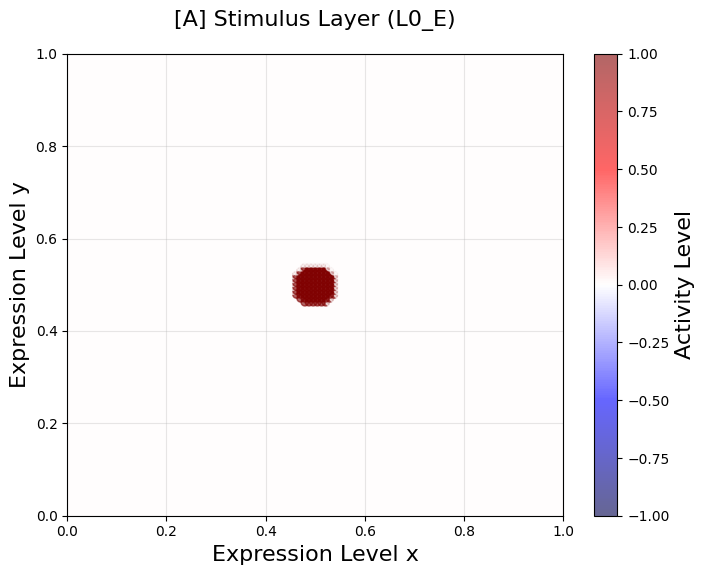

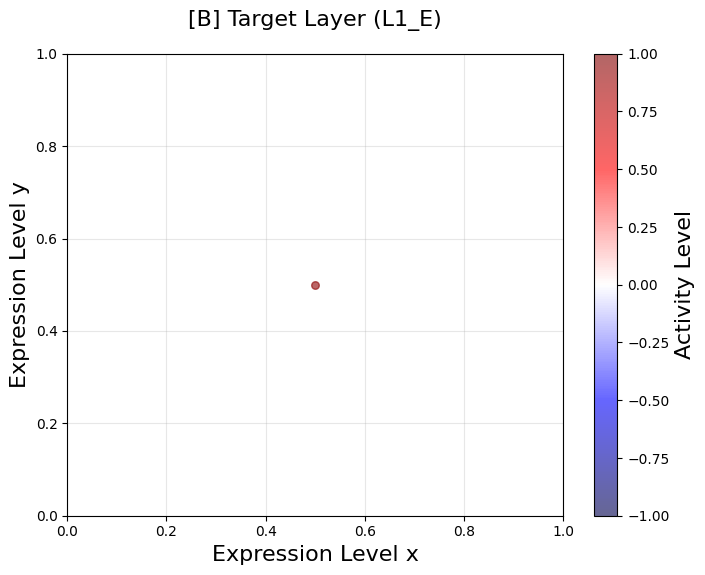

Center index:0


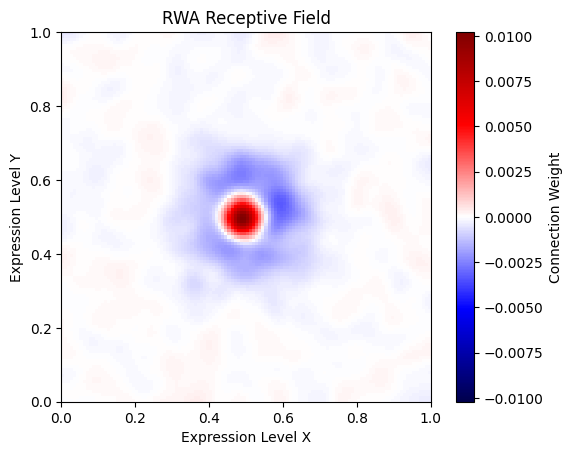

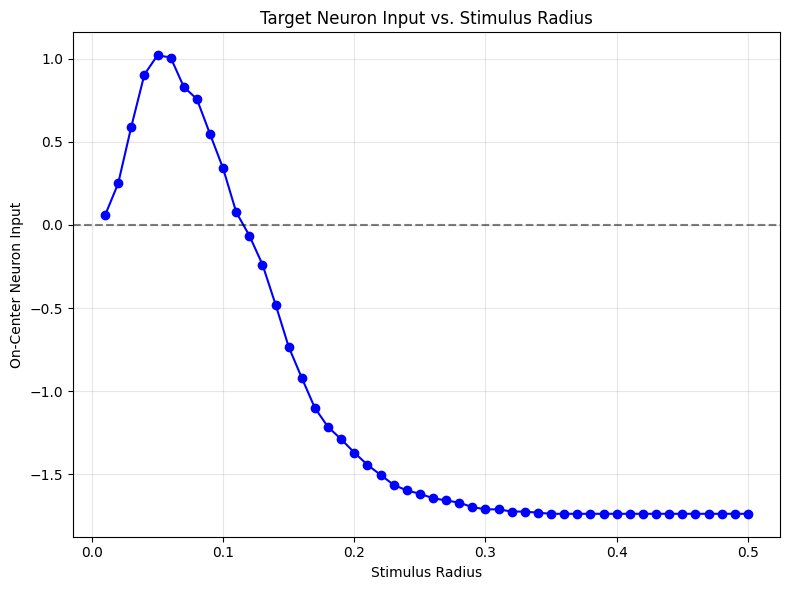

In [4]:
#############################
#    Verify Connectivity    #
#############################

W_0 = W_0_E + W_0_I

radius = sig_0_E * 1.5
cx = cy = 0.5

distances = np.sqrt((coords[:, 0] - cx) ** 2 + (coords[:, 1] - cy) ** 2)
stim_indices = np.where(distances <= radius)[0]

I_0 = np.zeros(N_L0_E)
I_0[stim_indices] = 1

x_0 = l_vals_L0_E[:, 0]
y_0 = l_vals_L0_E[:, 1]

plot_stim_act(I_0, x_0, y_0, title='[A] Stimulus Layer (L0_E)',
              xlabel='Expression Level x', ylabel='Expression Level y',
              cbar_label='Activity Level')

I_1 = W_0.T.dot(ReLU(I_0))
x_1 = l_vals_L1_E[:, 0]
y_1 = l_vals_L1_E[:, 1]

plot_stim_act(I_1, x_1, y_1, title='[B] Target Layer (L1_E)',
              xlabel='Expression Level x', ylabel='Expression Level y',
              cbar_label='Activity Level')

#############################
#        Find RWA RF        #
#############################

target_x, target_y = 0.50, 0.50
spatial_dist = np.sqrt((l_vals_L1_E[:, 0] - target_x)**2 + (l_vals_L1_E[:, 1] - target_y)**2)
center_idx = np.argmin(spatial_dist)
print(f'Center index:{center_idx}')

n_frames = 50000
stim = np.random.randn(n_frames, N_L0_E)

W_0_csc = W_0.tocsc()
W_eff = W_0_csc[:, center_idx].toarray().ravel()

acts = stim @ W_eff

rwa_flat = (acts @ stim) / n_frames

rwa_2d = rwa_flat.reshape(n, n)
rwa_2d = gaussian_filter(rwa_2d, sigma=3)

vmax_rwa = np.max(np.abs(rwa_2d))

fig, ax = plt.subplots()
im0 = ax.imshow(rwa_2d[::-1, :], cmap='seismic', vmin=-vmax_rwa, vmax=vmax_rwa, extent=[0, 1, 0, 1])
ax.set_title('RWA Receptive Field')
ax.set_xlabel('Expression Level X')
ax.set_ylabel('Expression Level Y')

plt.colorbar(im0, ax=ax, label='Connection Weight')

plt.show()

#############################
#        Radial Plot        #
#############################

radii = np.linspace(0.01, 0.5, 50)
activities = []

for r in radii:
    stim_indices_r = np.where(distances <= r)[0]
    
    I_0_r = np.zeros(N_L0_E)
    I_0_r[stim_indices_r] = 1
    
    I_1_r = W_0.T.dot(ReLU(I_0_r))
    activities.append(I_1_r[center_idx])

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(radii, activities, marker='o', linestyle='-', color='b')
ax.set_title('Target Neuron Input vs. Stimulus Radius')
ax.set_xlabel('Stimulus Radius')
ax.set_ylabel('On-Center Neuron Input')
ax.axhline(0, color='k', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Option 2: Decorrelate Inhibitory Receptors

 &emsp; 2.1. Build net<br>

In [ ]:
#############################
#          Params           #
#############################
np.random.seed(seed=187)

N_L0_E = 14400
N_L0_I = 14400
N_L1_E = 1

N = (N_L0_E + N_L0_I, N_L1_E)
n = int((N[0] / 2) ** (1 / 2))          
sig = 0.0001
sig_rec = 500*sig
K = 1

sig_0_E = 0.03
sig_0_I = 0.03
sig_00 =  0.003  


p_0 = 1

w_00  =  1.0/(N_L0_E*np.pi*((sig_00)**2)*p_0) 
w_0_E =  1.0 / (N_L0_E * np.pi * (sig_0_E ** 2) * p_0)
w_0_I = -1.0 / (N_L0_I * np.pi * (sig_0_I ** 2) * p_0)


#############################
#        Create Net         #
#############################

#layer 0
X, Y = np.meshgrid(np.linspace(0, 1, n), np.linspace(0, 1, n), indexing='xy')
coords = np.column_stack((X.ravel(), Y.ravel()))

layer_lig_E = coords
layer_rec_E = coords.copy()

xy_L0_I = np.random.rand(N_L0_I, 2)
layer_lig_I = xy_L0_I + sig * np.random.randn(N_L0_I, 2)
layer_rec_I = xy_L0_I + sig_rec * np.random.randn(N_L0_I, 2)

layer_lig_L0_combined = np.vstack((layer_lig_E, layer_lig_I))
layer_rec_L0_combined = np.vstack((layer_rec_E, layer_rec_I))

net = [[layer_lig_L0_combined, layer_rec_L0_combined]]

#layer 1

xy_E = np.random.rand(N_L1_E, 2)

xy_E[:,0] = xy_E[:,1] = 0.5 

xy_lig_E = xy_E + sig * np.random.randn(N_L1_E, 2)
xy_rec_E = xy_E + sig * np.random.randn(N_L1_E, 2)

net.append([xy_lig_E, xy_rec_E])

#############################
#    Create Connectivity    #
#############################

l_vals_L0_E = net[0][0][0:N_L0_E]
l_vals_L0_I = net[0][0][N_L0_E:]
r_vals_L0_E = net[0][1][0:N_L0_E]
r_vals_L0_I = net[0][1][N_L0_E:]
l_vals_L1_E = net[1][0]               


prob_00 = compute_prob_2d_sparse(r_vals_L0_E, l_vals_L0_I, sig_00)          
B_00 = sample_bernoulli_sparse(prob_00, K)
W_00 = (w_00 * B_00).tocsr()

B_L0E_L1E = sample_bernoulli_sparse(compute_prob_2d_sparse(r_vals_L0_E, l_vals_L1_E, sig_0_E), K)
B_L0I_L1E = sample_bernoulli_sparse(compute_prob_2d_sparse(r_vals_L0_I, l_vals_L1_E, sig_0_I), K)
W_0_E_block = (w_0_E * B_L0E_L1E).tocsr()
W_0_I_block = (w_0_I * B_L0I_L1E).tocsr()

W_0_E = W_0_E_block.tocsr()
W_0_I = (W_00 @ W_0_I_block).tocsr()



 &emsp; 2.2. Analyze net<br>

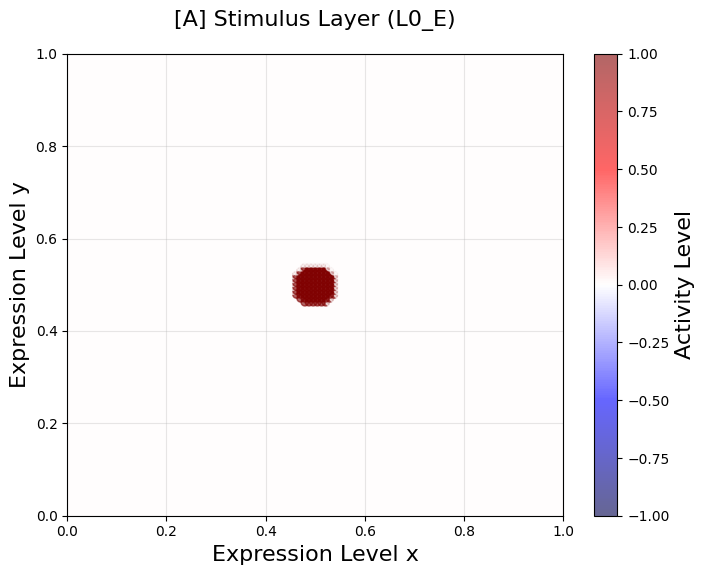

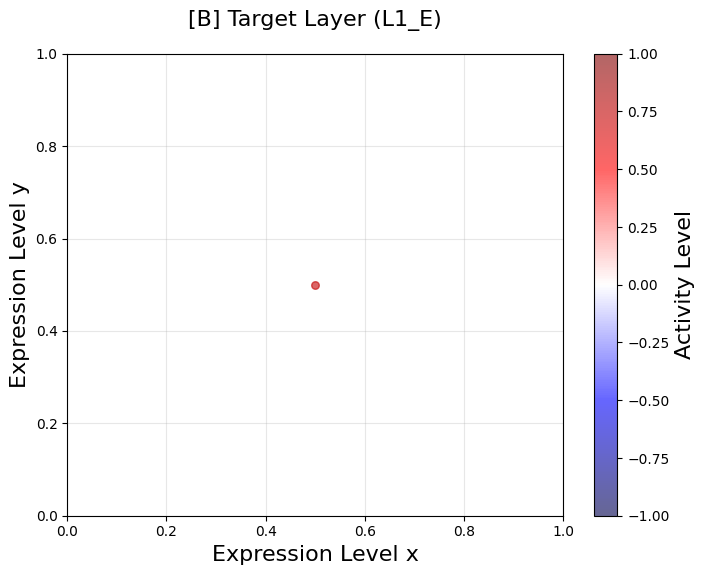

Center index:0


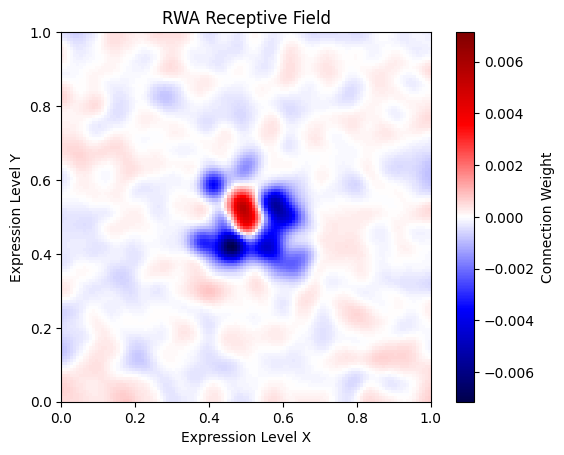

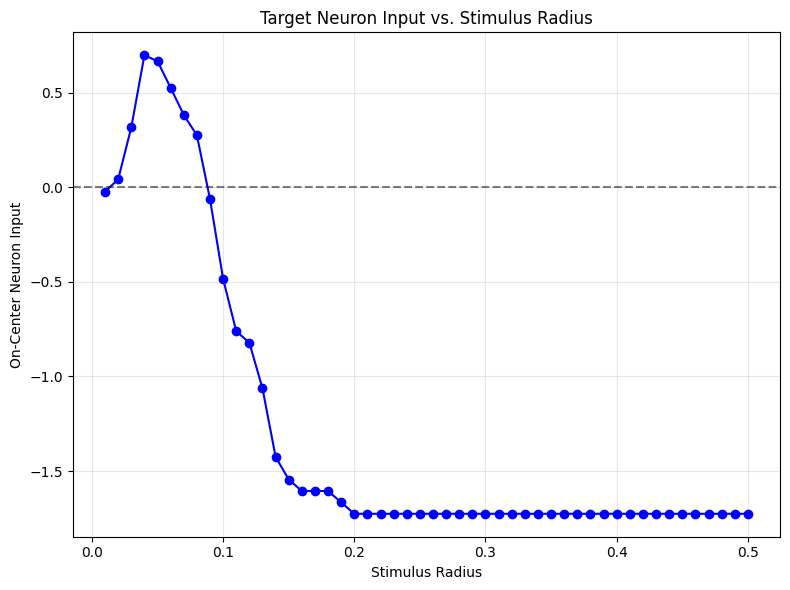

In [44]:
#############################
#    Verify Connectivity    #
#############################

W_0 = W_0_E + W_0_I

radius = sig_0_E * 1.5
cx = cy = 0.5

distances = np.sqrt((coords[:, 0] - cx) ** 2 + (coords[:, 1] - cy) ** 2)
stim_indices = np.where(distances <= radius)[0]

I_0 = np.zeros(N_L0_E)
I_0[stim_indices] = 1

x_0 = l_vals_L0_E[:, 0]
y_0 = l_vals_L0_E[:, 1]

plot_stim_act(I_0, x_0, y_0, title='[A] Stimulus Layer (L0_E)',
              xlabel='Expression Level x', ylabel='Expression Level y',
              cbar_label='Activity Level')

I_1 = W_0.T.dot(ReLU(I_0))
x_1 = l_vals_L1_E[:, 0]
y_1 = l_vals_L1_E[:, 1]

plot_stim_act(I_1, x_1, y_1, title='[B] Target Layer (L1_E)',
              xlabel='Expression Level x', ylabel='Expression Level y',
              cbar_label='Activity Level')

#############################
#        Find RWA RF        #
#############################

target_x, target_y = 0.50, 0.50
spatial_dist = np.sqrt((l_vals_L1_E[:, 0] - target_x)**2 + (l_vals_L1_E[:, 1] - target_y)**2)
center_idx = np.argmin(spatial_dist)
print(f'Center index:{center_idx}')

n_frames = 50000
stim = np.random.randn(n_frames, N_L0_E)

W_0_csc = W_0.tocsc()
W_eff = W_0_csc[:, center_idx].toarray().ravel()

acts = stim @ W_eff

rwa_flat = (acts @ stim) / n_frames

rwa_2d = rwa_flat.reshape(n, n)
rwa_2d = gaussian_filter(rwa_2d, sigma=3)

vmax_rwa = np.max(np.abs(rwa_2d))

fig, ax = plt.subplots()
im0 = ax.imshow(rwa_2d[::-1, :], cmap='seismic', vmin=-vmax_rwa, vmax=vmax_rwa, extent=[0, 1, 0, 1])
ax.set_title('RWA Receptive Field')
ax.set_xlabel('Expression Level X')
ax.set_ylabel('Expression Level Y')

plt.colorbar(im0, ax=ax, label='Connection Weight')

plt.show()

#############################
#        Radial Plot        #
#############################

radii = np.linspace(0.01, 0.5, 50)
activities = []

for r in radii:
    stim_indices_r = np.where(distances <= r)[0]
    
    I_0_r = np.zeros(N_L0_E)
    I_0_r[stim_indices_r] = 1
    
    I_1_r = W_0.T.dot(ReLU(I_0_r))
    activities.append(I_1_r[center_idx])

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(radii, activities, marker='o', linestyle='-', color='b')
ax.set_title('Target Neuron Input vs. Stimulus Radius')
ax.set_xlabel('Stimulus Radius')
ax.set_ylabel('On-Center Neuron Input')
ax.axhline(0, color='k', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Option 3: Fixed Num of Connections (Nearest Neighbourhood)

 &emsp; 3.1. Build net<br>

In [13]:
import scipy.sparse as sp

#############################
#          Params           #
#############################
np.random.seed(seed=187)

N_L0_E = 14400
N_L0_I = 14400
N_L1_E = 1

N = (N_L0_E + N_L0_I, N_L1_E)
n = int((N[0] / 2) ** (1 / 2))          
sig = 0.0001
K = 1


sig_0_E = 0.03
sig_0_I = 0.09
sig_00 =  0.01  

num_E = int(N_L1_E * np.pi * sig_0_E**2)
num_I = int(N_L1_E * np.pi * sig_0_I**2)

p_0 = 1

w_00  =  1.0 #/ (N_L0_E * np.pi * ((sig_00)**2) * p_0) 
w_0_E =  1.0 / (N_L0_E * np.pi * (sig_0_E ** 2) * p_0)
w_0_I = -1.0 / (N_L0_I * np.pi * (sig_0_I ** 2) * p_0)


#############################
#        Create Net         #
#############################

X, Y = np.meshgrid(np.linspace(0, 1, n), np.linspace(0, 1, n), indexing='xy')
coords = np.column_stack((X.ravel(), Y.ravel()))

layer_lig_E = coords
layer_rec_E = coords.copy()

xy_L0_I = np.random.rand(N_L0_I, 2)
layer_lig_I = xy_L0_I + sig * np.random.randn(N_L0_I, 2)
layer_rec_I = xy_L0_I + sig * np.random.randn(N_L0_I, 2)

layer_lig_L0_combined = np.vstack((layer_lig_E, layer_lig_I))
layer_rec_L0_combined = np.vstack((layer_rec_E, layer_rec_I))

net = [[layer_lig_L0_combined, layer_rec_L0_combined]]

xy_E = np.random.rand(N_L1_E, 2)
xy_E[:,0] = xy_E[:,1] = 0.5 

xy_lig_E = xy_E + sig * np.random.randn(N_L1_E, 2)
xy_rec_E = xy_E + sig * np.random.randn(N_L1_E, 2)

net.append([xy_lig_E, xy_rec_E])


#############################
#    Create Connectivity    #
#############################

l_vals_L0_E = net[0][0][0:N_L0_E]
l_vals_L0_I = net[0][0][N_L0_E:]
r_vals_L0_E = net[0][1][0:N_L0_E]
r_vals_L0_I = net[0][1][N_L0_E:]
l_vals_L1_E = net[1][0]               

def fixed_num_connectivity_sparse(sources, targets, num, sigma, weight):
    n_sources = sources.shape[0]
    n_targets = targets.shape[0]
    W = sp.lil_matrix((n_sources, n_targets), dtype=float)

    for i, src in enumerate(sources):
        d = np.sqrt(((targets - src) ** 2).sum(axis=1))
        in_range = np.where(d < sigma)[0]
        if len(in_range) > 0:
            np.random.shuffle(in_range)
            chosen = in_range[:num]
            W[i, chosen] = weight

    return W.tocsr()

W_00 = fixed_num_connectivity_sparse(r_vals_L0_E, l_vals_L0_I, num=1, sigma=sig_00, weight=w_00)
W_0_E_block = fixed_num_connectivity_sparse(r_vals_L0_E, l_vals_L1_E, num=1, sigma=sig_0_E, weight=w_0_E)
W_0_I_block = fixed_num_connectivity_sparse(r_vals_L0_I, l_vals_L1_E, num=1, sigma=sig_0_I, weight=w_0_I)

W_0_E = W_0_E_block
W_0_I = W_00 @ W_0_I_block

 &emsp; 3.2. Analyze net<br>

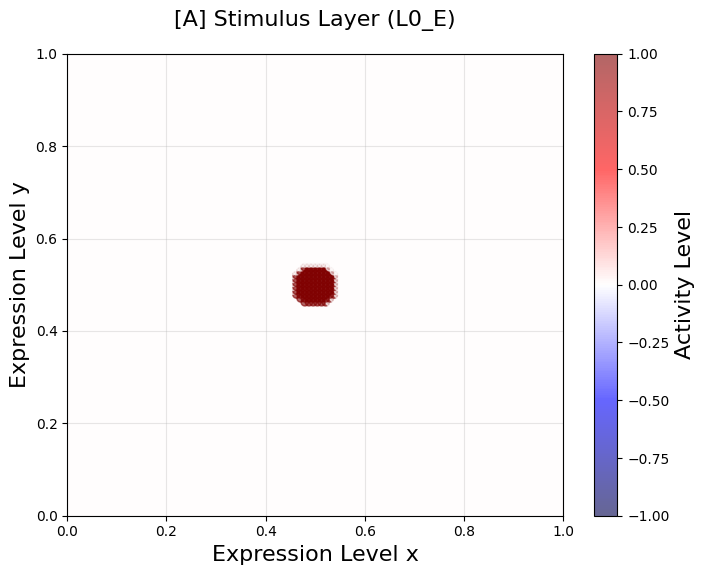

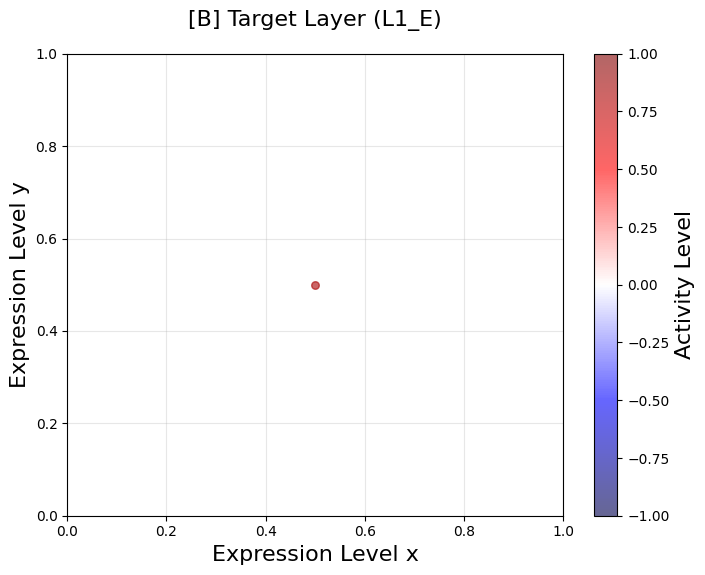

Center index:0


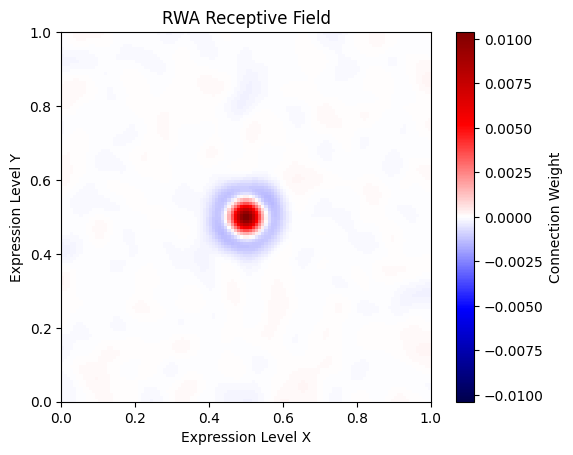

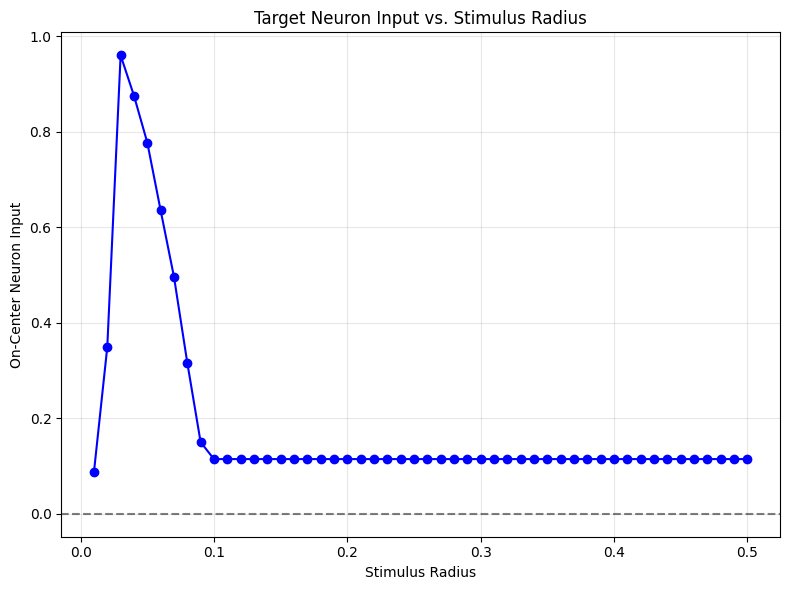

In [14]:
#############################
#    Verify Connectivity    #
#############################

W_0 = W_0_E + W_0_I

radius = sig_0_E * 1.5
cx = cy = 0.5

distances = np.sqrt((coords[:, 0] - cx) ** 2 + (coords[:, 1] - cy) ** 2)
stim_indices = np.where(distances <= radius)[0]

I_0 = np.zeros(N_L0_E)
I_0[stim_indices] = 1

x_0 = l_vals_L0_E[:, 0]
y_0 = l_vals_L0_E[:, 1]

plot_stim_act(I_0, x_0, y_0, title='[A] Stimulus Layer (L0_E)',
              xlabel='Expression Level x', ylabel='Expression Level y',
              cbar_label='Activity Level')

I_1 = W_0.T.dot(ReLU(I_0))
x_1 = l_vals_L1_E[:, 0]
y_1 = l_vals_L1_E[:, 1]

plot_stim_act(I_1, x_1, y_1, title='[B] Target Layer (L1_E)',
              xlabel='Expression Level x', ylabel='Expression Level y',
              cbar_label='Activity Level')

#############################
#        Find RWA RF        #
#############################

target_x, target_y = 0.50, 0.50
spatial_dist = np.sqrt((l_vals_L1_E[:, 0] - target_x)**2 + (l_vals_L1_E[:, 1] - target_y)**2)
center_idx = np.argmin(spatial_dist)
print(f'Center index:{center_idx}')

n_frames = 50000
stim = np.random.randn(n_frames, N_L0_E)

W_0_csc = W_0.tocsc()
W_eff = W_0_csc[:, center_idx].toarray().ravel()

acts = stim @ W_eff

rwa_flat = (acts @ stim) / n_frames

rwa_2d = rwa_flat.reshape(n, n)
rwa_2d = gaussian_filter(rwa_2d, sigma=3)

vmax_rwa = np.max(np.abs(rwa_2d))

fig, ax = plt.subplots()
im0 = ax.imshow(rwa_2d[::-1, :], cmap='seismic', vmin=-vmax_rwa, vmax=vmax_rwa, extent=[0, 1, 0, 1])
ax.set_title('RWA Receptive Field')
ax.set_xlabel('Expression Level X')
ax.set_ylabel('Expression Level Y')

plt.colorbar(im0, ax=ax, label='Connection Weight')

plt.show()

#############################
#        Radial Plot        #
#############################

radii = np.linspace(0.01, 0.5, 50)
activities = []

for r in radii:
    stim_indices_r = np.where(distances <= r)[0]
    
    I_0_r = np.zeros(N_L0_E)
    I_0_r[stim_indices_r] = 1
    
    I_1_r = W_0.T.dot(ReLU(I_0_r))
    activities.append(I_1_r[center_idx])

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(radii, activities, marker='o', linestyle='-', color='b')
ax.set_title('Target Neuron Input vs. Stimulus Radius')
ax.set_xlabel('Stimulus Radius')
ax.set_ylabel('On-Center Neuron Input')
ax.axhline(0, color='k', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()